# Building 4 and Building 6: October 2020 Forecasts
## 1. Setup
Use June–September to select models; evaluate October only (2,976 UTC 15-minute slots). Month-ahead forecasts are available at month start; rolling forecasts update hourly using completed previous hours. Report both resolutions and preserve missing targets. The forecast period follows the supplied October-only clarification.

Cached June–October fits can be reused after checking every target and score against phase_2_data.tsf. Set `REUSE_EXISTING_RESULTS=False` to train all models again. Observed weather is a scenario input for month-ahead; rolling weather lags one hour. Prior exploration means October is a historical comparison, not a fresh blind test.

In [1]:
from pathlib import Path
from datetime import datetime
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings, json, joblib, contextlib,io
ROOT=Path(r'C:\Users\50851\Documents\Codex\2026-08-14\kan')
CACHE=ROOT/'outputs/building46_monthahead'
OUT=ROOT/'outputs/building46_october';OUT.mkdir(exist_ok=True)
REUSE_EXISTING_RESULTS=True  # False refits every candidate from the TSF files.
DATA=Path(r'C:\Users\50851\Desktop\ADS2002\MonashSolarFarm')
LOCAL_TZ='Australia/Melbourne'
plt.rcParams.update({'font.size':10,'figure.dpi':110})


## 2. Load data through October and check coverage

In [2]:
def load_tsf(path):
    """
    Read a .tsf file.

    Returns a dict of {series_name: pandas Series}, each with a proper
    15-minute UTC DatetimeIndex reconstructed from its own start timestamp.
    """
    series = {}
    with open(path) as fh:
        for line in fh:
            line = line.rstrip("\n")

            # Skip comments, blank lines, and the @tag header lines.
            if not line or line.startswith("#") or line.startswith("@"):
                continue

            # Everything after @data has the shape  name:timestamp:v1,v2,v3,...
            name, timestamp, values = line.split(":", 2)

            # "2016-07-03 21-30-00"  ->  a real timestamp, tagged as UTC
            start = pd.Timestamp(datetime.strptime(timestamp, "%Y-%m-%d %H-%M-%S"), tz="UTC")

            # "?" marks a missing reading
            numbers = [np.nan if v == "?" else float(v) for v in values.split(",")]

            # Build the dates by stepping forward 15 minutes at a time
            index = pd.date_range(start=start, periods=len(numbers), freq="15min", tz="UTC")

            series[name] = pd.Series(numbers, index=index, name=name)
    return series



raw=pd.DataFrame(load_tsf(DATA/'phase_2_data.tsf')).asfreq('15min')
raw=raw.loc[raw.index < pd.Timestamp('2020-11-01',tz='UTC')]
assert raw.index.max()==pd.Timestamp('2020-10-31 23:45',tz='UTC')
hourly=raw.resample('h').mean()
wx=pd.read_csv(DATA/'ERA5_Weather_Data_Monash.csv')
wx.index=pd.to_datetime(wx.pop('datetime (UTC)'),utc=True)
wx=wx.select_dtypes('number').drop(columns=['utc_offset (hrs)'],errors='ignore').resample('h').mean()
wx=wx.loc[:,wx.nunique()>1]
folds={pd.Timestamp(f'2020-{m:02d}-01',tz='UTC').strftime('%b'):(pd.Timestamp(f'2020-{m:02d}-01',tz='UTC'),pd.Timestamp(f'2020-{m+1:02d}-01',tz='UTC')) for m in range(6,11)}
coverage=[]
for b in ['Building4','Building6']:
    for name,(lo,hi) in folds.items():
        z=raw.loc[(raw.index>=lo)&(raw.index<hi),b]
        coverage.append(dict(Building=b,Month=name,Expected=len(z),Observed=int(z.count()),Observed_pct=100*z.notna().mean()))
coverage=pd.DataFrame(coverage);display(coverage.round(2));coverage.to_csv(OUT/'coverage.csv',index=False)


,Building,Month,Expected,Observed,Observed_pct
0,Building4,Jun,2880,1978,68.68
1,Building4,Jul,2976,1712,57.53
2,Building4,Aug,2976,1469,49.36
3,Building4,Sep,2880,1151,39.97
4,Building4,Oct,2976,1691,56.82
5,Building6,Jun,2880,2874,99.79
6,Building6,Jul,2976,2972,99.87
7,Building6,Aug,2976,2967,99.70
8,Building6,Sep,2880,2876,99.86
9,Building6,Oct,2976,2972,99.87


## 3. Build supplied calendar, weather and long-lag features

In [3]:
calendar_code='import pandas as pd\nimport numpy as np\n\n# ============================================================\n# 0. PREPARE DATETIME INDEX\n# ============================================================\n\nFeature_dataset.index = pd.to_datetime(Feature_dataset.index)\nFeature_dataset = Feature_dataset.sort_index()\n\ndate = Feature_dataset.index.normalize()\nhour = Feature_dataset.index.hour\nminute = Feature_dataset.index.minute\ntime_minutes = hour * 60 + minute\n\n\n# ============================================================\n# 1. HELPER FUNCTION FOR DATE RANGES\n# ============================================================\n\ndef in_date_ranges(index, ranges):\n    dates = index.normalize()\n    mask = pd.Series(False, index=index)\n\n    for start, end in ranges:\n        start = pd.Timestamp(start)\n        end = pd.Timestamp(end)\n\n        mask |= (dates >= start) & (dates <= end)\n\n    return mask.astype(int).values\n\n\n# ============================================================\n# 2. WEEKDAY / WEEKEND\n# ============================================================\n\nFeature_dataset["is_weekday"] = (\n    Feature_dataset.index.dayofweek < 5\n).astype(int)\n\nFeature_dataset["is_weekend"] = (\n    Feature_dataset.index.dayofweek >= 5\n).astype(int)\n\n\n# ============================================================\n# 3. UNIVERSITY OPEN / CLOSED\n# ============================================================\n\nuniversity_open_ranges = [\n    ("2016-01-04", "2016-12-22"),\n    ("2017-01-03", "2017-12-21"),\n    ("2018-01-02", "2018-12-21"),\n    ("2019-01-02", "2019-12-23"),\n    ("2020-01-02", "2020-12-23"),\n]\n\nFeature_dataset["university_open"] = in_date_ranges(\n    Feature_dataset.index,\n    university_open_ranges\n)\n\nFeature_dataset["university_closed"] = (\n    1 - Feature_dataset["university_open"]\n)\n\n\n# ============================================================\n# 4. CAMPUS FACILITY HOURS\n# Mon-Fri: 09:00 - 17:00\n# ============================================================\n\ncampus_time_open = (\n    (time_minutes >= 9 * 60) &\n    (time_minutes < 17 * 60)\n)\n\nFeature_dataset["campus_facility_hours"] = (\n    (Feature_dataset["is_weekday"] == 1) &\n    campus_time_open\n).astype(int)\n\n\n# ============================================================\n# 5. LIBRARY OPENING HOURS\n#\n# Weekdays: 08:00 - 22:00\n# Weekends: 10:00 - 17:00\n# ============================================================\n\nweekday_library = (\n    (Feature_dataset["is_weekday"] == 1) &\n    (time_minutes >= 8 * 60) &\n    (time_minutes < 22 * 60)\n)\n\nweekend_library = (\n    (Feature_dataset["is_weekend"] == 1) &\n    (time_minutes >= 10 * 60) &\n    (time_minutes < 17 * 60)\n)\n\nFeature_dataset["library_open_hours"] = (\n    weekday_library | weekend_library\n).astype(int)\n\n\n# ============================================================\n# 6. SEMESTER 1\n# ============================================================\n\nsemester_1_ranges = [\n    ("2016-02-29", "2016-05-27"),\n    ("2017-02-21", "2017-05-26"),\n    ("2018-02-26", "2018-05-25"),\n    ("2019-03-04", "2019-05-31"),\n    ("2020-03-09", "2020-06-12"),\n]\n\nFeature_dataset["semester_1"] = in_date_ranges(\n    Feature_dataset.index,\n    semester_1_ranges\n)\n\n\n# ============================================================\n# 7. SEMESTER 2\n# ============================================================\n\nsemester_2_ranges = [\n    ("2016-07-25", "2016-10-21"),\n    ("2017-07-24", "2017-10-20"),\n    ("2018-07-23", "2018-10-19"),\n    ("2019-07-29", "2019-10-25"),\n    ("2020-08-03", "2020-11-06"),\n]\n\nFeature_dataset["semester_2"] = in_date_ranges(\n    Feature_dataset.index,\n    semester_2_ranges\n)\n\nFeature_dataset["semester_active"] = (\n    (Feature_dataset["semester_1"] == 1) |\n    (Feature_dataset["semester_2"] == 1)\n).astype(int)\n\n\n# ============================================================\n# 8. MID-SEMESTER BREAK\n# ============================================================\n\nmid_sem_break_ranges = [\n    ("2016-03-25", "2016-04-01"),\n    ("2016-09-26", "2016-09-30"),\n\n    ("2017-04-14", "2017-04-21"),\n    ("2017-09-25", "2017-09-29"),\n\n    ("2018-03-30", "2018-04-06"),\n    ("2018-09-24", "2018-09-28"),\n\n    ("2019-04-19", "2019-04-26"),\n    ("2019-09-30", "2019-10-04"),\n\n    ("2020-04-10", "2020-04-17"),\n    ("2020-09-21", "2020-10-02"),\n]\n\nFeature_dataset["mid_sem_break"] = in_date_ranges(\n    Feature_dataset.index,\n    mid_sem_break_ranges\n)\n\n\n# ============================================================\n# 9. ORIENTATION WEEK\n# ============================================================\n\norientation_ranges = [\n    ("2016-02-22", "2016-02-26"),\n    ("2016-07-18", "2016-07-22"),\n\n    ("2017-02-20", "2017-02-24"),\n    ("2017-07-17", "2017-07-21"),\n\n    ("2018-02-19", "2018-02-23"),\n    ("2018-07-16", "2018-07-20"),\n\n    ("2019-02-25", "2019-03-01"),\n    ("2019-07-22", "2019-07-26"),\n\n    # Semester 1 2020 not listed\n    ("2020-07-27", "2020-07-31"),\n]\n\nFeature_dataset["orientation_week"] = in_date_ranges(\n    Feature_dataset.index,\n    orientation_ranges\n)\n\n\n# ============================================================\n# 10. SWOT VAC\n# ============================================================\n\nswotvac_ranges = [\n    ("2016-05-30", "2016-06-03"),\n    ("2016-10-24", "2016-10-28"),\n\n    ("2017-05-29", "2017-06-02"),\n    ("2017-10-23", "2017-10-27"),\n\n    ("2018-05-28", "2018-06-01"),\n    ("2018-10-22", "2018-10-26"),\n\n    ("2019-06-03", "2019-06-07"),\n    ("2019-10-28", "2019-11-01"),\n\n    ("2020-06-15", "2020-06-19"),\n    ("2020-11-09", "2020-11-13"),\n]\n\nFeature_dataset["swotvac"] = in_date_ranges(\n    Feature_dataset.index,\n    swotvac_ranges\n)\n\n\n# ============================================================\n# 11. EXAM PERIOD\n# ============================================================\n\nexam_ranges = [\n    ("2016-06-06", "2016-06-24"),\n    ("2016-10-31", "2016-11-18"),\n\n    ("2017-06-05", "2017-06-23"),\n    ("2017-10-30", "2017-11-17"),\n\n    ("2018-06-04", "2018-06-22"),\n    ("2018-10-29", "2018-11-16"),\n\n    ("2019-06-10", "2019-06-28"),\n    ("2019-11-04", "2019-11-22"),\n\n    ("2020-06-22", "2020-07-10"),\n    ("2020-11-16", "2020-12-04"),\n]\n\nFeature_dataset["exam_period"] = in_date_ranges(\n    Feature_dataset.index,\n    exam_ranges\n)\n\n\n# ============================================================\n# 12. REMOTE EXAMS - 2020\n# ============================================================\n\nFeature_dataset["remote_exam"] = in_date_ranges(\n    Feature_dataset.index,\n    [("2020-06-22", "2020-07-10")]\n)\n\n\n# ============================================================\n# 13. PUBLIC HOLIDAYS\n# ============================================================\n\npublic_holidays = pd.to_datetime([\n\n    # 2016\n    "2016-01-26",\n    "2016-03-25",\n    "2016-03-28",\n    "2016-03-29",\n    "2016-04-25",\n    "2016-09-30",\n    "2016-12-25",\n    "2016-12-26",\n\n    # 2017\n    "2017-01-26",\n    "2017-04-14",\n    "2017-04-17",\n    "2017-04-18",\n    "2017-04-25",\n    "2017-09-29",\n    "2017-12-25",\n    "2017-12-26",\n\n    # 2018\n    "2018-01-01",\n    "2018-01-26",\n    "2018-03-30",\n    "2018-04-02",\n    "2018-04-03",\n    "2018-04-25",\n    "2018-09-28",\n    "2018-12-25",\n    "2018-12-26",\n\n    # 2019\n    "2019-01-01",\n    "2019-01-28",\n    "2019-04-19",\n    "2019-04-22",\n    "2019-04-23",\n    "2019-04-25",\n    "2019-09-27",\n    "2019-12-25",\n    "2019-12-26",\n\n    # 2020\n    "2020-01-01",\n    "2020-01-27",\n    "2020-04-10",\n    "2020-04-13",\n    "2020-04-14",\n    "2020-04-25",\n    "2020-10-23",\n    "2020-12-25",\n    "2020-12-28",\n])\n\nFeature_dataset["public_holiday"] = (\n    date.isin(public_holidays)\n).astype(int)\n\n\n# ============================================================\n# 14. COVID DISRUPTION\n# 9 March 2020 onward\n# ============================================================\n\nFeature_dataset["covid_disruption"] = (\n    date >= pd.Timestamp("2020-03-09")\n).astype(int)\n\n\n# ============================================================\n# 15. ONLINE CLASSES\n# 9 - 13 March 2020\n# ============================================================\n\nFeature_dataset["online_classes"] = in_date_ranges(\n    Feature_dataset.index,\n    [("2020-03-09", "2020-03-13")]\n)\n\n\n# ============================================================\n# 16. COVID CAMPUS RESTRICTIONS\n# 16 March - 18 October 2020\n# ============================================================\n\nFeature_dataset["covid_restrictions"] = in_date_ranges(\n    Feature_dataset.index,\n    [("2020-03-16", "2020-10-18")]\n)\n\n\n# ============================================================\n# 17. COVID CURFEW PERIOD\n# 2 August - 13 September 2020\n# ============================================================\n\nFeature_dataset["covid_curfew_period"] = in_date_ranges(\n    Feature_dataset.index,\n    [("2020-08-02", "2020-09-13")]\n)\n\n\n# ============================================================\n# 18. EFFECTIVE CAMPUS OPEN\n#\n# Combines:\n# - University open\n# - Weekday\n# - 9am-5pm\n# - Not public holiday\n# - Not COVID restricted\n# ============================================================\n\nFeature_dataset["campus_facility_effectively_open"] = (\n    (Feature_dataset["university_open"] == 1) &\n    (Feature_dataset["is_weekday"] == 1) &\n    campus_time_open &\n    (Feature_dataset["public_holiday"] == 0) &\n    (Feature_dataset["covid_restrictions"] == 0)\n).astype(int)\n\n\n# ============================================================\n# 19. EFFECTIVE LIBRARY OPEN\n# ============================================================\n\nFeature_dataset["library_effectively_open"] = (\n    (Feature_dataset["library_open_hours"] == 1) &\n    (Feature_dataset["university_open"] == 1) &\n    (Feature_dataset["public_holiday"] == 0) &\n    (Feature_dataset["covid_restrictions"] == 0)\n).astype(int)\n\n\n# ============================================================\n# 20. TEACHING DAY\n# ============================================================\n\nFeature_dataset["teaching_day"] = (\n    (Feature_dataset["semester_active"] == 1) &\n    (Feature_dataset["is_weekday"] == 1) &\n    (Feature_dataset["mid_sem_break"] == 0) &\n    (Feature_dataset["public_holiday"] == 0)\n).astype(int)\n\n\n# ============================================================\n# 21. CHECK THE CREATED FEATURES\n# ============================================================\n\nfeature_columns = [\n    "is_weekday",\n    "is_weekend",\n    "university_open",\n    "university_closed",\n    "campus_facility_hours",\n    "library_open_hours",\n    "semester_1",\n    "semester_2",\n    "semester_active",\n    "mid_sem_break",\n    "orientation_week",\n    "swotvac",\n    "exam_period",\n    "remote_exam",\n    "public_holiday",\n    "covid_disruption",\n    "online_classes",\n    "covid_restrictions",\n    "covid_curfew_period",\n    "campus_facility_effectively_open",\n    "library_effectively_open",\n    "teaching_day",\n]\n\nprint(Feature_dataset[feature_columns].head())\nprint("\\nFeature counts:")\nprint(Feature_dataset[feature_columns].sum())\n'
ix=hourly.index
ns={'Feature_dataset':pd.DataFrame(index=ix.tz_convert(LOCAL_TZ).tz_localize(None))}
with contextlib.redirect_stdout(io.StringIO()):exec(calendar_code,ns)
x=ns['Feature_dataset'].drop(columns=['is_weekend','university_closed','semester_active'],errors='ignore');x.index=ix
local=ix.tz_convert(LOCAL_TZ)
for name,v,period in [('hour',local.hour,24),('dayofyear',local.dayofyear,366),('weekday',local.dayofweek,7)]:
    x[name+'_sin']=np.sin(2*np.pi*v/period);x[name+'_cos']=np.cos(2*np.pi*v/period)
x['hour']=local.hour;x['weekday']=local.dayofweek;x['month']=local.month
x=x.join(wx)
assert x.loc['2020-06-01':'2020-10-31'].notna().all().all(),'Forecast weather missing: do not fabricate.'
history={}
for b in ['Building4','Building6']:
    extra=pd.DataFrame(index=ix)
    for name in list(dict.fromkeys([b,'Building5','Building6','Solar1','Solar2','Solar3','Solar4','Solar5'])):
        extra[name+'_35d']=hourly[name].shift(35*24)
        extra[name+'_past24h_at35d']=hourly[name].shift(35*24).rolling(24,min_periods=1).mean()
    history[b]=extra
for lo,hi in folds.values():assert hi-pd.Timedelta(days=35)<lo
print('All lagged source timestamps precede each monthly origin; no current-month usage enters prediction.')


All lagged source timestamps precede each monthly origin; no current-month usage enters prediction.


## 4. Monthly models
Fit or reuse the unchanged monthly candidates on June–October folds.

In [4]:
if REUSE_EXISTING_RESULTS:
    scores=pd.read_csv(CACHE/'all_month_scores.csv')
    scores=scores[scores.Month.isin(folds)].copy()
    all_forecasts=pd.read_csv(CACHE/'all_model_forecasts_15min.csv',parse_dates=['timestamp_UTC'])
    all_forecasts['timestamp_UTC']=pd.to_datetime(all_forecasts.timestamp_UTC,utc=True)
    all_forecasts=all_forecasts[all_forecasts.Month.isin(folds)].copy()
    scores.to_csv(OUT/'all_month_scores.csv',index=False)
    all_forecasts.to_csv(OUT/'all_model_forecasts_15min.csv',index=False)
    print('Reused unchanged June–October fits; input/score checks run below.')
else:
    def scaled(m):return make_pipeline(StandardScaler(),m)
    models={
     'Ridge':scaled(Ridge(alpha=100)),
     'Random Forest':RandomForestRegressor(n_estimators=100,max_depth=12,min_samples_leaf=12,max_features=.8,n_jobs=2,random_state=42),
     'Extra Trees':ExtraTreesRegressor(n_estimators=100,max_depth=12,min_samples_leaf=12,max_features=.8,n_jobs=2,random_state=42),
     'KNN':scaled(KNeighborsRegressor(n_neighbors=40,weights='distance')),
     'SVR':TransformedTargetRegressor(regressor=scaled(SVR(C=1,epsilon=.1)),transformer=StandardScaler()),
     'Neural Network':TransformedTargetRegressor(regressor=scaled(MLPRegressor(hidden_layer_sizes=(24,),alpha=1,max_iter=200,early_stopping=False,random_state=42)),transformer=StandardScaler()),
     'Reference GB':GradientBoostingRegressor(n_estimators=150,learning_rate=.05,max_depth=2,min_samples_leaf=8,random_state=42),
     'MAE HGB':HistGradientBoostingRegressor(loss='absolute_error',max_iter=150,learning_rate=.04,max_leaf_nodes=15,min_samples_leaf=40,l2_regularization=10,early_stopping=False,random_state=42)}
    def metrics(b,lo,actual,pred):
        ok=actual.notna();a=actual[ok].to_numpy();p=np.asarray(pred)[ok.to_numpy()]
        s=raw.loc[raw.index<lo,b];diff=(s-s.shift(2688)).abs().dropna();scale=diff.mean()
        assert scale>0 and np.isfinite(p).all()
        return dict(MASE=np.mean(np.abs(a-p))/scale,RMSE=mean_squared_error(a,p)**.5,MAE=mean_absolute_error(a,p),R2=r2_score(a,p),Within10pct=100*np.mean(np.abs(a-p)<=.1*np.abs(a)),Observed_points=len(a),MASE_scale=scale)
    def fit_model(est,X,y):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always',ConvergenceWarning)
            m=clone(est).fit(X,y)
        return m,'; '.join(str(w.message) for w in caught if issubclass(w.category,ConvergenceWarning))
    scores=[];forecasts=[]
    def record(b,mon,name,p,train_n,used=0,warning=''):
        lo,hi=folds[mon];target=pd.date_range(lo,hi,freq='15min',inclusive='left')
        f=pd.Series(np.maximum(np.asarray(p),0),index=pd.date_range(lo,hi,freq='h',inclusive='left')).reindex(target,method='ffill')
        assert len(f)==int((hi-lo)/pd.Timedelta('15min')) and f.notna().all()
        a=raw[b].reindex(target)
        scores.append(dict(Building=b,Month=mon,Model=name,Train_hours=train_n,History_used_hours=used,Warning=warning,**metrics(b,lo,a,f)))
        forecasts.append(pd.DataFrame({'timestamp_UTC':target,'Building':b,'Month':mon,'Model':name,'predicted_kW':f.to_numpy(),'actual_kW':a.to_numpy()}))
    for b in ['Building4','Building6']:
        y=hourly[b]
        for mon,(lo,hi) in folds.items():
            ev=pd.date_range(lo,hi,freq='h',inclusive='left')
            tr=y.index[(y.index<lo)&y.notna()&x.notna().all(axis=1)]
            Y=y.loc[tr];X=x.loc[tr];E=x.loc[ev]
            record(b,mon,'Training median',np.repeat(raw.loc[raw.index<lo,b].median(),len(ev)),len(tr))
            keys=lo-pd.Timedelta(days=28)+(ev-lo)%pd.Timedelta(days=28)
            seasonal=y.reindex(keys).to_numpy();seasonal=np.where(np.isfinite(seasonal),seasonal,Y.median())
            record(b,mon,'28-day cycle',seasonal,len(tr))
            for name,est in models.items():
                m,w=fit_model(est,X,Y);p=m.predict(E);record(b,mon,name,p,len(tr),warning=w)
                if mon in ['Oct']:joblib.dump({'model':m,'columns':list(X.columns),'origin':lo},OUT/f'{b}_{mon}_{name.replace(" ","_")}.joblib')
                if name in ['Random Forest','Extra Trees','MAE HGB']:
                    aug=x.join(history[b]);atr=tr[aug.loc[tr].notna().all(axis=1)]
                    ae=ev[aug.loc[ev].notna().all(axis=1)]
                    q=p.copy()
                    if len(atr)>=100 and len(ae):
                        am,aw=fit_model(est,aug.loc[atr],y.loc[atr]);q[ev.get_indexer(ae)]=am.predict(aug.loc[ae])
                    else:aw='History model unavailable; base fallback only'
                    record(b,mon,name+' + history35d',q,len(atr),len(ae) if len(atr)>=100 else 0,aw)
            pd.DataFrame(scores).to_csv(OUT/'all_month_scores.csv',index=False)
            print(b,mon,'done',flush=True)
            (OUT/'progress.txt').write_text(b+' '+mon+' done',encoding='utf-8')
    scores=pd.DataFrame(scores);all_forecasts=pd.concat(forecasts,ignore_index=True)
    all_forecasts.to_csv(OUT/'all_model_forecasts_15min.csv',index=False)


Reused unchanged June–October fits; input/score checks run below.


## 5. Rolling features
Use measurements lagged by at least one hour. Assume completed-hour readings arrive at the next hour boundary.

In [5]:
from sklearn.impute import SimpleImputer
ROLL_OUT = OUT / 'rolling_comparison'
ROLL_OUT.mkdir(exist_ok=True)

def causal_features(building, include_peers=True, data=hourly, weather=wx):
    # Calendar values are known in advance; all measured features lag at least one hour.
    f=x.drop(columns=list(wx.columns)).reindex(data.index).copy()
    f=f.join(weather.reindex(data.index).shift(1).add_prefix('weather_previous_hour_'))
    series=[building]
    if include_peers:
        series=list(dict.fromkeys(series+['Building5','Building6','Solar1','Solar2','Solar3','Solar4','Solar5']))
    for name in series:
        s=data[name]
        for lag in ([1,2,24,48,168] if name==building else [1,24]):
            f[f'{name}_lag{lag}h']=s.shift(lag)
        f[f'{name}_past24h_mean']=s.shift(1).rolling(24,min_periods=6).mean()
    return f

# Confirm that changing all current/future observations cannot change a forecast's inputs.
check_time=pd.Timestamp('2020-10-15 12:00',tz='UTC')
changed=hourly.copy(); changed.loc[check_time:]=99999
changed_weather=wx.copy(); changed_weather.loc[check_time:]=99999
rolling_features={}
for building in ['Building4','Building6']:
    for peers in [False,True]:
        f=causal_features(building,peers)
        altered=causal_features(building,peers,changed,changed_weather)
        pd.testing.assert_series_equal(f.loc[check_time],altered.loc[check_time])
        rolling_features[(building,peers)]=f
print('Passed: no current/future measured values enter the rolling feature row.')


Passed: no current/future measured values enter the rolling feature row.


## 6. Rolling models
Fit or reuse persistence, Gradient Boosting, Random Forest and Extra Trees, with optional lagged peer/solar data. Imputation is fitted on training features; targets stay observed.

In [6]:
rolling_estimators={
    'Gradient Boosting':GradientBoostingRegressor(n_estimators=180,learning_rate=.05,max_depth=3,min_samples_leaf=3,random_state=42),
    'Random Forest':RandomForestRegressor(n_estimators=120,max_depth=16,min_samples_leaf=3,n_jobs=2,random_state=42),
    'Extra Trees':ExtraTreesRegressor(n_estimators=120,max_depth=16,min_samples_leaf=3,n_jobs=2,random_state=42),
}

def evaluate_forecast(actual,prediction,scale):
    observed=actual.notna()
    a=actual.loc[observed].to_numpy();p=prediction.loc[observed].to_numpy()
    nonzero=a!=0
    assert np.isfinite(p).all()
    return dict(RMSE=np.sqrt(np.mean((a-p)**2)),MAE=np.mean(abs(a-p)),R2=r2_score(a,p),
                MASE=np.mean(abs(a-p))/scale,
                Within10pct=100*np.mean(abs(a[nonzero]-p[nonzero])<=.1*abs(a[nonzero])),
                Observed_points=len(a),Nonzero_points=int(nonzero.sum()))

if REUSE_EXISTING_RESULTS:
    rolling_scores=pd.read_csv(CACHE/'rolling_comparison/all_rolling_scores.csv')
    rolling_scores=rolling_scores[rolling_scores.Month.isin(folds)].copy()
    rolling_predictions=pd.read_csv(CACHE/'rolling_comparison/all_rolling_predictions.csv',parse_dates=['timestamp_UTC'])
    rolling_predictions['timestamp_UTC']=pd.to_datetime(rolling_predictions.timestamp_UTC,utc=True)
    rolling_predictions=rolling_predictions[rolling_predictions.Month.isin(folds)].copy()
    rolling_scores.to_csv(ROLL_OUT/'all_rolling_scores.csv',index=False)
    rolling_predictions.to_csv(ROLL_OUT/'all_rolling_predictions.csv',index=False)
else:
    rolling_scores=[];rolling_predictions=[]
    for building in ['Building4','Building6']:
        y=hourly[building]
        for month,(start,end) in folds.items():
            ev=pd.date_range(start,end,freq='h',inclusive='left')
            train=y.index[(y.index<start)&y.notna()]
            raw_train=raw.loc[raw.index<start,building]
            scale15=(raw_train-raw_train.shift(2688)).abs().mean()
            hour_train=y.loc[y.index<start]
            scaleh=(hour_train-hour_train.shift(672)).abs().mean()
            candidate_predictions={'Persistence':y.shift(1).reindex(ev).fillna(y.loc[train].median())}
            for peers in [False,True]:
                f=rolling_features[(building,peers)]
                for name,estimator in rolling_estimators.items():
                    label=name+(' + peers/solar' if peers else '')
                    pipeline=make_pipeline(SimpleImputer(strategy='median',add_indicator=True),clone(estimator))
                    pipeline.fit(f.loc[train],y.loc[train])
                    prediction=pd.Series(np.maximum(pipeline.predict(f.loc[ev]),0),index=ev)
                    candidate_predictions[label]=prediction
                    if month in ['Oct']:
                        joblib.dump({'model':pipeline,'feature_columns':list(f.columns),'origin':start,
                                     'measured_feature_lag_hours':1},
                                    ROLL_OUT/f'{building}_{month}_{label.replace(" /", "_").replace("/", "_")}.joblib')
            for name,p in candidate_predictions.items():
                idx15=pd.date_range(start,end,freq='15min',inclusive='left')
                p15=p.reindex(idx15,method='ffill')
                assert len(p15)==len(idx15) and p15.notna().all()
                for grain,a,pr,scale in [('Hourly',y.reindex(ev),p,scaleh),
                                         ('15-minute',raw[building].reindex(idx15),p15,scale15)]:
                    rolling_scores.append(dict(Building=building,Month=month,Model=name,Grain=grain,
                                               **evaluate_forecast(a,pr,scale)))
                rolling_predictions.append(pd.DataFrame({'timestamp_UTC':idx15,'Building':building,
                    'Month':month,'Model':name,'predicted_kW':p15.values,'actual_kW':raw[building].reindex(idx15).values}))
            pd.DataFrame(rolling_scores).to_csv(ROLL_OUT/'all_rolling_scores.csv',index=False)
            print(building,month,'rolling models complete',flush=True)
    rolling_scores=pd.DataFrame(rolling_scores)
    rolling_predictions=pd.concat(rolling_predictions,ignore_index=True)
    rolling_predictions.to_csv(ROLL_OUT/'all_rolling_predictions.csv',index=False)
    rolling_validation=rolling_scores[(rolling_scores.Month.isin(['Jun','Jul','Aug','Sep'])) &
                                     (rolling_scores.Grain=='Hourly')].groupby(['Building','Model']).RMSE.mean()
    rolling_winners={b:rolling_validation.loc[b].idxmin() for b in ['Building4','Building6']}
    display(rolling_validation.unstack(0).round(4))
    print('Selected by June–September hourly RMSE:',rolling_winners)


## 7. October performance and energy
Select independently by validation RMSE and validation ±10% match rate. Match rate excludes zero targets. Baselines remain eligible; high match rate alone can hide poor peak prediction. No October-based reselection. Saved rolling predictions are a sequence of hourly forecasts, not a month-start forecast.

In [7]:
import matplotlib.dates as mdates
start,end=folds['Oct']
idx15=pd.date_range(start,end,freq='15min',inclusive='left')
assert len(idx15)==2976
summary=[];selected_predictions=[]

# Audit reused or refitted forecasts against the current phase-2 snapshot and saved scores.
for forecast_table,score_table in [(all_forecasts,scores),(rolling_predictions,rolling_scores[rolling_scores.Grain=='15-minute'])]:
    for (building,month,model),z in forecast_table.groupby(['Building','Month','Model']):
        lo,hi=folds[month]
        expected=pd.date_range(lo,hi,freq='15min',inclusive='left')
        z=z.set_index('timestamp_UTC').sort_index()
        assert z.index.equals(expected) and z.predicted_kW.notna().all()
        actual=raw[building].reindex(expected)
        np.testing.assert_allclose(z.actual_kW,actual,equal_nan=True)
        assert (z.predicted_kW>=0).all()
        pre=raw.loc[raw.index<lo,building];scale=(pre-pre.shift(2688)).abs().mean()
        audited=evaluate_forecast(actual,z.predicted_kW,scale)
        row=score_table[(score_table.Building==building)&(score_table.Month==month)&(score_table.Model==model)].iloc[0]
        for metric in ['RMSE','MAE','R2','MASE','Within10pct']:
            assert np.isclose(audited[metric],row[metric]),(building,month,model,metric)

monthly_validation=scores[scores.Month.isin(['Jun','Jul','Aug','Sep'])].groupby(['Building','Model'])[['RMSE','MASE','Within10pct']].mean()
rolling_validation=rolling_scores[(rolling_scores.Month.isin(['Jun','Jul','Aug','Sep']))&(rolling_scores.Grain=='Hourly')].groupby(['Building','Model'])[['RMSE','Within10pct']].mean()
display(rolling_validation.unstack(0).round(4))

for building in ['Building4','Building6']:
    candidates=[
        ('Month-ahead','MASE',all_forecasts,monthly_validation.loc[building,'MASE'].idxmin()),
        ('Month-ahead','RMSE',all_forecasts,monthly_validation.loc[building,'RMSE'].idxmin()),
        ('Rolling next-hour','RMSE',rolling_predictions,rolling_validation.loc[building,'RMSE'].idxmin()),
        ('Rolling next-hour','Match rate',rolling_predictions,rolling_validation.loc[building,'Within10pct'].idxmax())]
    for mode,objective,table,name in candidates:
        z=table[(table.Building==building)&(table.Month=='Oct')&(table.Model==name)].copy().set_index('timestamp_UTC').sort_index()
        assert z.index.equals(idx15)
        z['Mode']=mode;z['Selection']=objective;z['predicted_kWh']=z.predicted_kW*.25
        z.to_csv(OUT/f'{building}_October_{mode.replace(" ","_")}_{objective.replace(" ","_")}.csv')
        selected_predictions.append(z.reset_index())
        for grain in ['Hourly','15-minute']:
            p=z.predicted_kW if grain=='15-minute' else z.predicted_kW.resample('h').mean()
            actual=raw[building].reindex(p.index) if grain=='15-minute' else hourly[building].reindex(p.index)
            pre=raw.loc[raw.index<start,building] if grain=='15-minute' else hourly.loc[hourly.index<start,building]
            lag=2688 if grain=='15-minute' else 672
            scale=(pre-pre.shift(lag)).abs().mean()
            summary.append(dict(Building=building,Mode=mode,Selection=objective,Model=name,Grain=grain,
                                **evaluate_forecast(actual,p,scale)))
summary=pd.DataFrame(summary)
summary.to_csv(OUT/'October_performance.csv',index=False)
display(summary.round(4))
predictions=pd.concat(selected_predictions,ignore_index=True)
assert summary.groupby(['Building','Grain']).Observed_points.nunique().eq(1).all()
energy=predictions.groupby(['Building','Mode','Selection']).predicted_kWh.sum().rename('October_predicted_kWh')
energy.to_csv(OUT/'October_predicted_energy.csv');display(energy.round(2))
print('Verified all June–October forecasts, targets and scores. October evaluation has 2976 forecast slots per building.')


RMSE           Within10pct          
Building                        Building4 Building6   Building4 Building6
Model                                                                    
Extra Trees                        0.4198    1.6244     29.8137   97.7466
Extra Trees + peers/solar          0.4212    1.6062     27.4876   97.3644
Gradient Boosting                  0.4111    1.6214     29.6621   97.4015
Gradient Boosting + peers/solar    0.4133    1.6055     29.4142   97.2971
Persistence                        0.5502    2.3092     38.9556   89.6019
Random Forest                      0.4127    1.6399     30.2199   97.8196
Random Forest + peers/solar        0.4177    1.6330     30.0019   97.4686

,Building,Mode,Selection,Model,Grain,RMSE,MAE,R2,MASE,Within10pct,Observed_points,Nonzero_points
0,Building4,Month-ahead,MASE,Training median,Hourly,0.4628,0.2650,-0.4878,0.7534,59.8639,735,735
1,Building4,Month-ahead,MASE,Training median,15-minute,0.5339,0.2555,-0.2970,0.5637,75.9314,1691,1691
2,Building4,Month-ahead,RMSE,Random Forest,Hourly,0.3568,0.2671,0.1155,0.7594,28.2993,735,735
3,Building4,Month-ahead,RMSE,Random Forest,15-minute,0.4570,0.3514,0.0499,0.7754,17.3862,1691,1691
4,Building4,Rolling next-hour,RMSE,Gradient Boosting,Hourly,0.3621,0.2779,0.0889,0.7903,26.6667,735,735
5,Building4,Rolling next-hour,RMSE,Gradient Boosting,15-minute,0.4618,0.3637,0.0295,0.8024,16.0852,1691,1691
6,Building4,Rolling next-hour,Match rate,Persistence,Hourly,0.4888,0.3118,-0.6601,0.8866,48.5714,735,735
7,Building4,Rolling next-hour,Match rate,Persistence,15-minute,0.5640,0.3572,-0.4472,0.7881,49.7930,1691,1691
8,Building6,Month-ahead,MASE,Extra Trees + history35d,Hourly,2.7506,1.9975,0.7741,0.8006,78.7634,744,744
9,Building6,Month-ahead,MASE,Extra Trees + history35d,15-minute,3.0453,2.2899,0.7356,0.7737,72.8129,2972,2972


Building   Mode               Selection 
Building4  Month-ahead        MASE            744.00
                              RMSE            917.67
           Rolling next-hour  Match rate      938.75
                              RMSE            927.21
Building6  Month-ahead        MASE          22380.20
                              RMSE          22380.20
           Rolling next-hour  Match rate    22606.92
                              RMSE          22688.57
Name: October_predicted_kWh, dtype: float64

Verified all June–October forecasts, targets and scores. October evaluation has 2976 forecast slots per building.


## 8. October charts
Compare matching targets and show the entire month. All labels and scores identify their resolution.

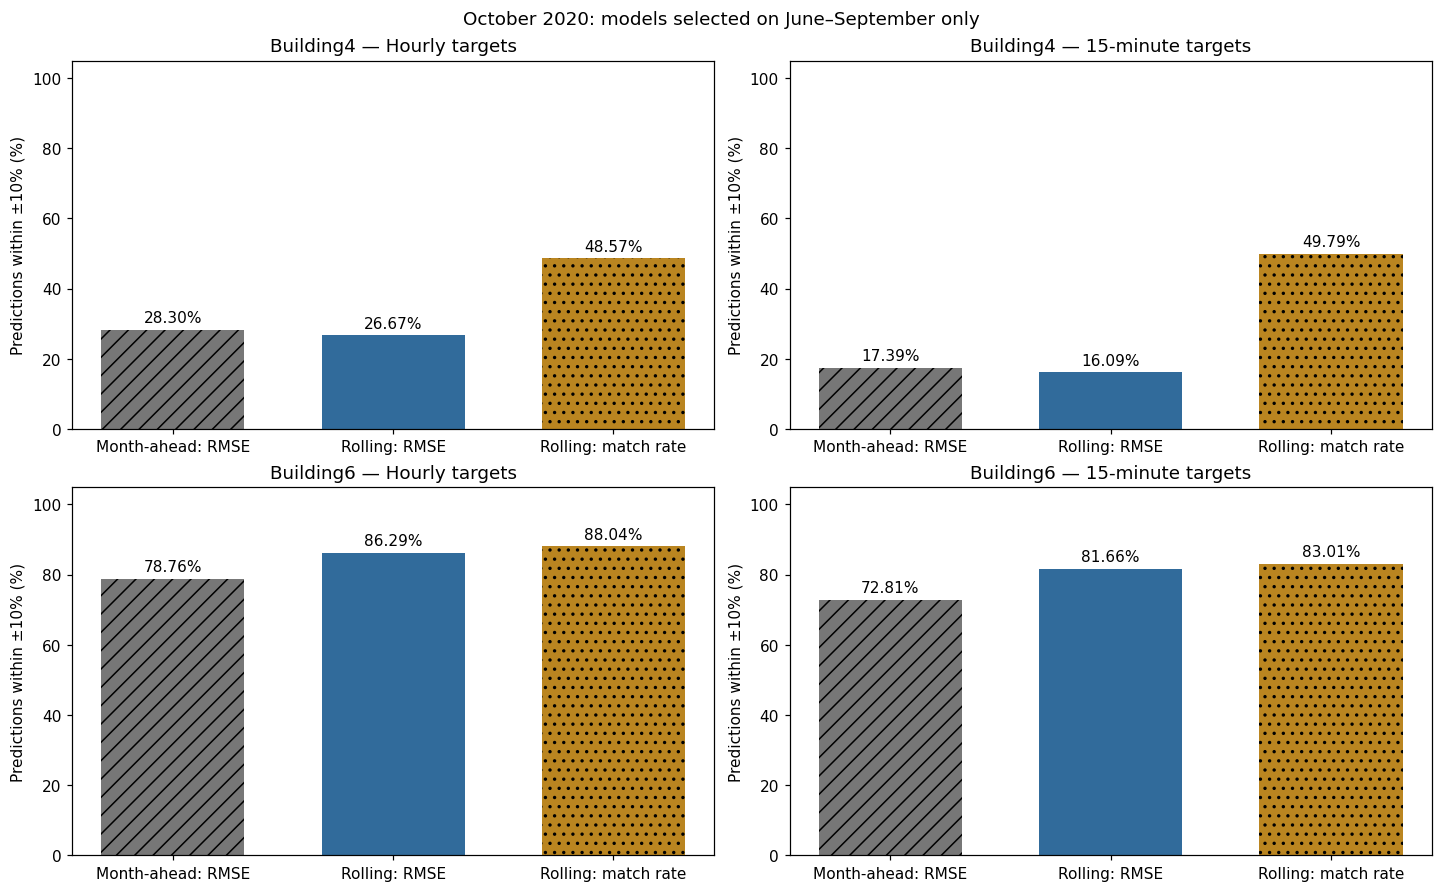

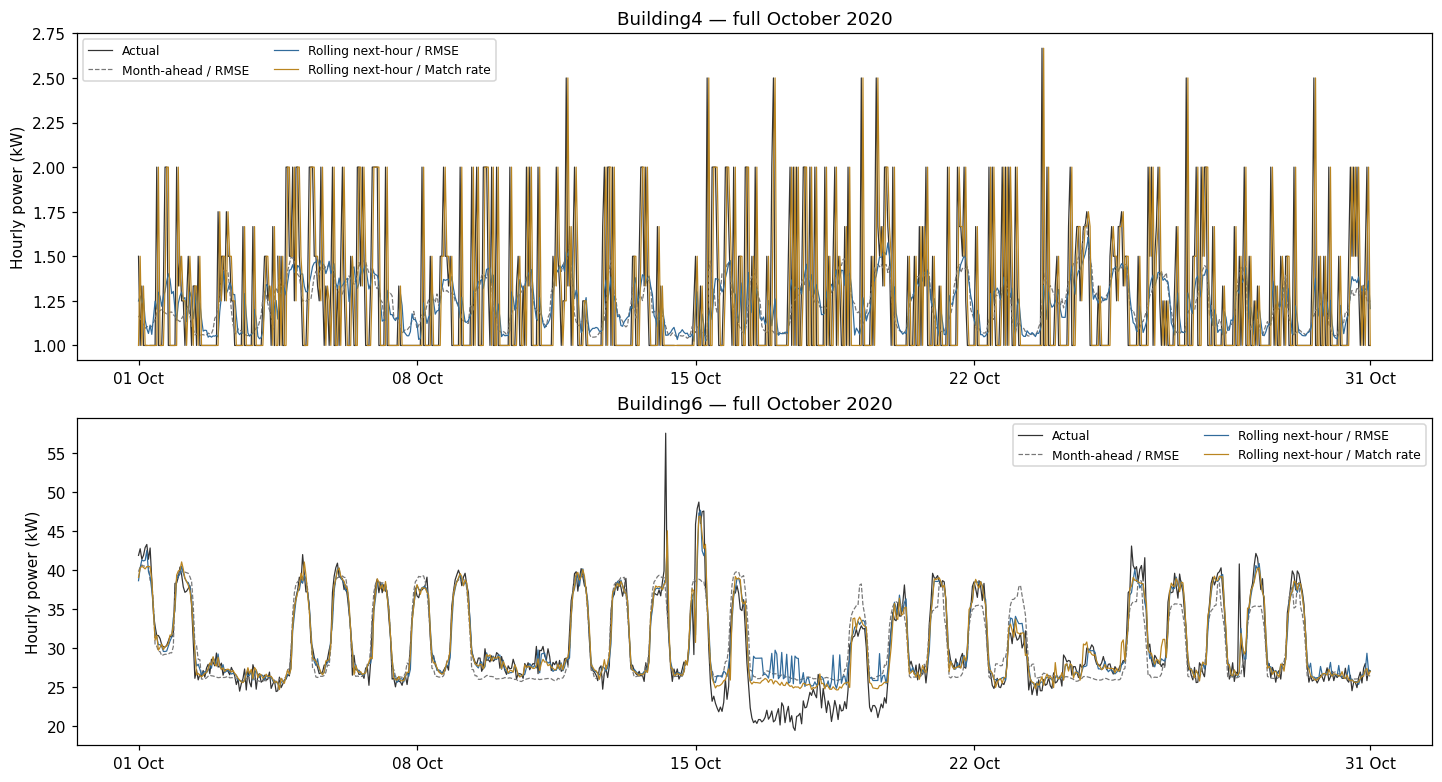

In [8]:
styles=[('Month-ahead','RMSE','#777777','//'),('Rolling next-hour','RMSE','#316b9b',''),('Rolling next-hour','Match rate','#ba8520','..')]
labels=['Month-ahead: RMSE','Rolling: RMSE','Rolling: match rate']
fig,axes=plt.subplots(2,2,figsize=(13,8),layout='constrained')
for i,building in enumerate(['Building4','Building6']):
    for j,grain in enumerate(['Hourly','15-minute']):
        ax=axes[i,j]
        for k,(mode,objective,color,hatch) in enumerate(styles):
            r=summary[(summary.Building==building)&(summary.Grain==grain)&(summary.Mode==mode)&(summary.Selection==objective)].iloc[0]
            bar=ax.bar(k,r.Within10pct,color=color,hatch=hatch,width=.65)
            ax.bar_label(bar,fmt='%.2f%%',padding=3)
        ax.set_xticks(range(3),labels);ax.set_ylim(0,105)
        ax.set_ylabel('Predictions within ±10% (%)');ax.set_title(building+' — '+grain+' targets')
fig.suptitle('October 2020: models selected on June–September only')
fig.savefig(OUT/'October_match_rates.png',dpi=150);plt.show()

fig,axes=plt.subplots(2,1,figsize=(13,7),layout='constrained')
for ax,building in zip(axes,['Building4','Building6']):
    ax.plot(hourly.loc[(hourly.index>=start)&(hourly.index<end)].index,
            hourly.loc[(hourly.index>=start)&(hourly.index<end),building],color='#333333',label='Actual',linewidth=.8)
    for mode,objective,color,hatch in styles:
        z=predictions[(predictions.Building==building)&(predictions.Mode==mode)&(predictions.Selection==objective)].set_index('timestamp_UTC')
        z=z.predicted_kW.resample('h').mean()
        ax.plot(z.index,z,label=mode+' / '+objective,color=color,linewidth=.8,linestyle='--' if mode=='Month-ahead' else '-')
    ax.set_title(building+' — full October 2020');ax.set_ylabel('Hourly power (kW)');ax.legend(fontsize=8,ncol=2)
    ax.set_xticks([start,start+pd.Timedelta(days=7),start+pd.Timedelta(days=14),start+pd.Timedelta(days=21),end-pd.Timedelta(hours=1)])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.savefig(OUT/'October_actual_vs_predicted.png',dpi=150);plt.show()
